In [1]:
import os
import math
import numpy as np
import xarray as xr
import scipy.ndimage
from pathlib import Path
import netCDF4 as nc
import cc3d
import gc
import metpy
from metpy.calc import density
from metpy.units import units
import matplotlib.pyplot as plt
import scipy.linalg
import metpy.calc as mpcalc

#Constants
L_v = 2.5 * (10**6) #latent heat
c_pd = 1004 #specific heat
p_0 = 10**5 #reference pressure
R_d = 287
R_v = 461.5

t = 6
t_conds = 18

In [2]:
#Open datasets
ds_p = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/p.nc", decode_times=False,chunks={'time': 1}) #pressure
ds_initial_thermo_conds = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/eurec4a.default.0000000.nc",group='thermo', decode_times=False,chunks={'time': 1}).isel(time=t_conds) #initial conds
ds_initial_general_conds = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/eurec4a.default.0000000.nc",group='default', decode_times=False,chunks={'time': 1}).isel(time=t_conds) #initial conds
ds_w = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/w.nc", decode_times=False,chunks={'time': 1}).rename({'zh':'z'}).interp(z=ds_p.z)
ds_u = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/u.nc", decode_times=False,chunks={'time': 1}).rename({'xh':'x'}).interp(x=ds_p.x)
ds_v = xr.open_dataset("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/v.nc", decode_times=False,chunks={'time': 1}).rename({'yh':'y'}).interp(y=ds_p.y)

/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/xarray/core/dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [3]:
#extract initial cond variables
rho_o = ds_initial_thermo_conds.rhoref
u_o = ds_initial_general_conds.u
v_o = ds_initial_general_conds.v


In [4]:
#-create th-
th_da = mpcalc.potential_temperature(
    ds_initial_general_conds.p.values * units.pascal, 
    ds_initial_thermo_conds.T.values * units.kelvin
).magnitude

# Replace any top-of-atmosphere Infs or NaNs with standard neighboring numbers
th_da = np.nan_to_num(th_da, nan=300.0, posinf=300.0, neginf=300.0)

# If the top grid point is bad, backfill it with the layer just below it
if not np.isfinite(th_da[-1]):
    th_da[-1] = th_da[-2]

th = xr.DataArray(th_da, coords={"z": ds_initial_thermo_conds.z}, dims=["z"])


/mnt/stor-pool-01/users/2821011/.local/lib/python3.9/site-packages/pint/facets/plain/quantity.py:1271: RuntimeWarning: invalid value encountered in power
  magnitude = new_self._magnitude**exponent


In [5]:
#slicing
p_slice = ds_p.isel(time=t).p
u_slice = ds_u.isel(time=t).u
v_slice = ds_v.isel(time=t).v
w_slice = ds_w.isel(time=t).w


In [6]:
#Big V' calc (V-Vo)
#where V is (u,v) and Vo is (u_o, v_o)
u_prime = u_slice - u_o
v_prime = v_slice - v_o

In [7]:
#Calculate VPG
ds_vpg = p_slice.differentiate("z")

In [8]:
#Function
def solve_generalized_poisson_3d(f, sigma, z_coords, dx, dy):
    """
    Solves the 3D generalized Poisson equation on a vertically stretched grid:
        grad dot (sigma(z) * grad(m)) = f(x, y, z)
    """
    nz, ny, nx = f.shape
    
    # 1. Horizontal Fourier Transform of the RHS source term
    f_hat = np.fft.rfft2(f, axes=(1, 2))
    
    # 2. Compute symmetric horizontal wavenumbers squared (kx^2 + ky^2)
    kx = np.fft.rfftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    k_sq = ky[:, np.newaxis]**2 + kx[np.newaxis, :]**2
    nkx = len(kx)
    
    # 3. Compute exact stretched grid metrics from true simulation centers
    dz_center = np.diff(z_coords)                 # Distance between centers (nz - 1)
    zh = 0.5 * (z_coords[:-1] + z_coords[1:])     # Reconstructed half-levels (nz - 1)
    dz_cell = np.diff(zh)                         # Thickness of interior cells (nz - 2)
    
    dz_cell_bottom = z_coords[1] - z_coords[0]
    dz_cell_top = z_coords[-1] - z_coords[-2]
    
    sigma_half = 0.5 * (sigma[:-1] + sigma[1:])   # Length: nz - 1
    
    # 4. Pre-compute the shared vertical operators (Built ONCE outside loops)
    interior_lower = sigma_half[:-1] / (dz_cell * dz_center[:-1])
    interior_upper = sigma_half[1:] / (dz_cell * dz_center[1:])
    
    # Allocate template for the base tridiagonal matrix
    ab_base = np.zeros((3, nz), dtype=complex)
    
    # Fill vertical terms for interior rows
    ab_base[2, :-2] = interior_lower               # Corrected lower diagonal shift
    ab_base[0, 2:]  = interior_upper               # Corrected upper diagonal shift
    ab_base[1, 1:-1] = -interior_upper - interior_lower
    
    # Fill vertical terms for boundary cap rows (Neumann boundary conditions)
    ab_base[1, 0]  = -sigma_half[0] / (dz_cell_bottom * dz_center[0])
    ab_base[0, 1]  =  sigma_half[0] / (dz_cell_bottom * dz_center[0])
    
    ab_base[1, -1] = -sigma_half[-1] / (dz_cell_top * dz_center[-1])
    ab_base[2, -2] =  sigma_half[-1] / (dz_cell_top * dz_center[-1])
    
    # Initialize container for the Fourier-space solution
    m_hat = np.zeros_like(f_hat, dtype=complex)
    
    # 5. Fast Execution Loop
    for r in range(ny):
        for c in range(nkx):
            ksq_rc = k_sq[r, c]
            
            if r == 0 and c == 0:
                m_hat[:, r, c] = 0.0
                continue
                
            # Copy the pre-computed base vertical structure 
            ab = ab_base.copy()
            
            # Layer the horizontal curvature decay on top of the main diagonal
            ab[1, :] -= sigma * ksq_rc
            
            # Instantaneous 1D tridiagonal solver execution
            m_hat[:, r, c] = scipy.linalg.solve_banded((1, 1), ab, f_hat[:, r, c])
            
    # 6. Transform back to real physical space
    m = np.fft.irfft2(m_hat, s=(ny, nx), axes=(1, 2))
    
    return m

In [9]:
#--Obtaining sigma (part of the left hand side excluding pi)--

#Equations
#DL : grad dot (cp * th * grad(pi DN)) = -grad dot (rho_o * V' dot grad V )
#DN : grad dot (cp * th * grad(pi DL)) = - rho_o * grad w * dV_o/dz
sigma_numpy = (c_pd * th).compute().values
if sigma_numpy.ndim > 1: #leakage protection
    sigma_numpy = sigma_numpy[0]

In [10]:
#--Obtaining f' (right hand side)--

#Equations
#DN : grad dot (cp * th * grad(pi DN)) = -grad dot (rho_o * V' dot grad V )
#DL : grad dot (cp * th * grad(pi DL)) = - rho_o * grad w * dV_o/dz

#DN
advection_x = u_prime * u_prime.differentiate("x") + v_prime * u_prime.differentiate("y")
advection_y = u_prime * v_prime.differentiate("x") + v_prime * v_prime.differentiate("y")

flux_x = rho_o * advection_x
flux_y = rho_o * advection_y

div_x = flux_x.differentiate("x")
div_y = flux_y.differentiate("y")

f_DN = -(div_x + div_y)


#DL
dw_dx = w_slice.differentiate("x")
dw_dy = w_slice.differentiate("y")

du0_dz = u_o.differentiate("z")
dv0_dz = v_o.differentiate("z")

f_DL = -rho_o * (dw_dx * du0_dz + dw_dy * dv0_dz)

In [11]:
#Preparing to compute
f_DN_numpy = f_DN.compute().values
f_DL_numpy = f_DL.compute().values
f_DN_numpy = np.nan_to_num(f_DN_numpy, nan=0.0) #clean f
f_DL_numpy = np.nan_to_num(f_DL_numpy, nan=0.0) #clean f

#dx, dy, z vals
dx = float(ds_p.x[1] - ds_p.x[0])
dy = float(ds_p.y[1] - ds_p.y[0])
z_numpy = ds_p.z.compute().values

In [12]:
#Performing Fourier analysis to find pi'_DN
pi_DN_numpy = solve_generalized_poisson_3d(
    f=f_DN_numpy, 
    sigma=sigma_numpy, 
    z_coords=z_numpy, 
    dx=dx, 
    dy=dy
)

pi_DN_xr = xr.DataArray(
    pi_DN_numpy, 
    coords={"z": ds_p.z, "y": ds_p.y, "x": ds_p.x}, 
    dims=["z", "y", "x"]
)

In [ ]:
# =====================================================================
# VERIFICATION CHECKER FOR PI_DN (Identical Stencil Matching)
# =====================================================================

# 1. Reconstruct Solver Horizontal Wavenumbers
nx, ny = pi_DN_xr.sizes["x"], pi_DN_xr.sizes["y"]
kx = np.fft.rfftfreq(nx, d=dx) * 2 * np.pi
ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
k_sq = ky[:, np.newaxis]**2 + kx[np.newaxis, :]**2

# 2. Compute Horizontal Laplacian Perfectly in Spectral Space
pi_b_hat = np.fft.rfft2(pi_DN_numpy, axes=(1, 2))
sigma_3d = sigma_numpy[:, np.newaxis, np.newaxis]
horizontal_laplacian_hat = -sigma_3d * k_sq[np.newaxis, :, :] * pi_b_hat
horizontal_laplacian_spectral = np.fft.irfft2(horizontal_laplacian_hat, s=(ny, nx), axes=(1, 2))

# 3. Compute Vertical Divergence using Solver Staggered Grid Metrics
dz_center = np.diff(z_numpy)
zh = 0.5 * (z_numpy[:-1] + z_numpy[1:])
dz_cell = np.diff(zh)
sigma_half = 0.5 * (sigma_numpy[:-1] + sigma_numpy[1:])

# Vertical Flux at half-levels (j + 1/2) -> Shape: (nz-1, ny, nx)
flux_z_half = sigma_half[:, np.newaxis, np.newaxis] * (np.diff(pi_DN_xr.values, axis=0) / dz_center[:, np.newaxis, np.newaxis])

# Flux Divergence at interior cell centers (j) -> Shape: (nz-2, ny, nx)
diff_2_z_interior = np.diff(flux_z_half, axis=0) / dz_cell[:, np.newaxis, np.newaxis]

# 4. Combine LHS Components & Extract Truth Target (Interior Rows 1 to nz-1)
test_lhs_spectral = horizontal_laplacian_spectral[1:-1, :, :] + diff_2_z_interior
truth_interior = f_DN_numpy[1:-1, :, :]

# 5. Numerical Execution Verification
correlation = np.corrcoef(test_lhs_spectral.flatten(), truth_interior.flatten())[0, 1]
print(f"Pure Spectral-Aligned Spatial Correlation for DN: {correlation:.6f}")

if np.allclose(test_lhs_spectral, truth_interior, rtol=1e-2, atol=1e-2):
    print(f"Verification of DN: SUCCESS - Solver approximately matches mathematical formulation")
else:
    print(f"Verification of DN: FAILURE - Discrepancies found.")

Verification of DN: SUCCESS - Solver approximately matches mathematical formulation


In [14]:
#Performing Fourier analysis to find pi'_DL
pi_DL_numpy = solve_generalized_poisson_3d(
    f=f_DL_numpy, 
    sigma=sigma_numpy, 
    z_coords=z_numpy, 
    dx=dx, 
    dy=dy
)

pi_DL_xr = xr.DataArray(
    pi_DL_numpy, 
    coords={"z": ds_p.z, "y": ds_p.y, "x": ds_p.x}, 
    dims=["z", "y", "x"]
)

In [ ]:
# =====================================================================
# VERIFICATION CHECKER FOR PI_DL (Identical Stencil Matching)
# =====================================================================

# 1. Reconstruct Solver Horizontal Wavenumbers
nx, ny = pi_DL_xr.sizes["x"], pi_DL_xr.sizes["y"]
kx = np.fft.rfftfreq(nx, d=dx) * 2 * np.pi
ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
k_sq = ky[:, np.newaxis]**2 + kx[np.newaxis, :]**2

# 2. Compute Horizontal Laplacian Perfectly in Spectral Space
pi_b_hat = np.fft.rfft2(pi_DL_numpy, axes=(1, 2))
sigma_3d = sigma_numpy[:, np.newaxis, np.newaxis]
horizontal_laplacian_hat = -sigma_3d * k_sq[np.newaxis, :, :] * pi_b_hat
horizontal_laplacian_spectral = np.fft.irfft2(horizontal_laplacian_hat, s=(ny, nx), axes=(1, 2))

# 3. Compute Vertical Divergence using Solver Staggered Grid Metrics
dz_center = np.diff(z_numpy)
zh = 0.5 * (z_numpy[:-1] + z_numpy[1:])
dz_cell = np.diff(zh)
sigma_half = 0.5 * (sigma_numpy[:-1] + sigma_numpy[1:])

# Vertical Flux at half-levels (j + 1/2) -> Shape: (nz-1, ny, nx)
flux_z_half = sigma_half[:, np.newaxis, np.newaxis] * (np.diff(pi_DL_xr.values, axis=0) / dz_center[:, np.newaxis, np.newaxis])

# Flux Divergence at interior cell centers (j) -> Shape: (nz-2, ny, nx)
diff_2_z_interior = np.diff(flux_z_half, axis=0) / dz_cell[:, np.newaxis, np.newaxis]

# 4. Combine LHS Components & Extract Truth Target (Interior Rows 1 to nz-1)
test_lhs_spectral = horizontal_laplacian_spectral[1:-1, :, :] + diff_2_z_interior
truth_interior = f_DL_numpy[1:-1, :, :]

# 5. Numerical Execution Verification
correlation = np.corrcoef(test_lhs_spectral.flatten(), truth_interior.flatten())[0, 1]
print(f"Pure Spectral-Aligned Spatial Correlation for DL: {correlation:.6f}")

if np.allclose(test_lhs_spectral, truth_interior, rtol=1e-2, atol=1e-2):
    print(f"Verification of DL: SUCCESS - Solver approximately matches mathematical formulation")
else:
    print(f"Verification of DL: FAILURE - Discrepancies found.")

Verification of DL: SUCCESS - Solver approximately matches mathematical formulation


In [21]:
#VPG DN
dpi_DN_dz_xr = pi_DN_xr.differentiate(coord="z")
vpg_DN_numpy = -c_pd * th.values[:, np.newaxis, np.newaxis] * dpi_DN_dz_xr.compute().values
vpg_DN_xr = xr.DataArray(
    vpg_DN_numpy, 
    coords={"z": ds_p.z, "y": ds_p.y, "x": ds_p.x}, 
    dims=["z", "y", "x"]
)

In [22]:
#VPG DL
dpi_DL_dz_xr = pi_DL_xr.differentiate(coord="z")
vpg_DL_numpy = -c_pd * th.values[:, np.newaxis, np.newaxis] * dpi_DL_dz_xr.compute().values
vpg_DL_xr = xr.DataArray(
    vpg_DL_numpy, 
    coords={"z": ds_p.z, "y": ds_p.y, "x": ds_p.x}, 
    dims=["z", "y", "x"]
)

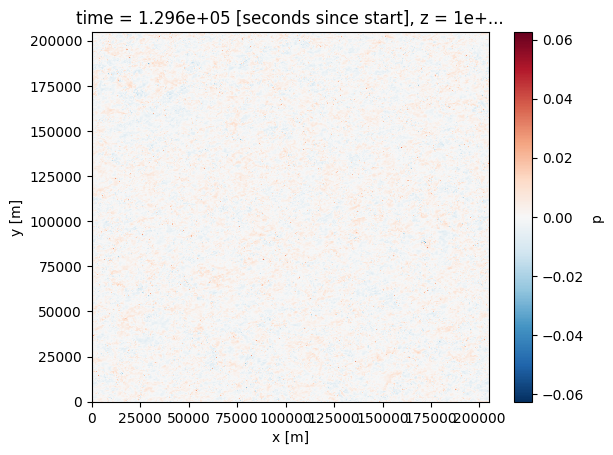

In [32]:
ds_vpg.sel(z=1000, method="nearest").plot(x="x",y="y",vmin=-0.0625,vmax=0.0625,cmap='RdBu_r')

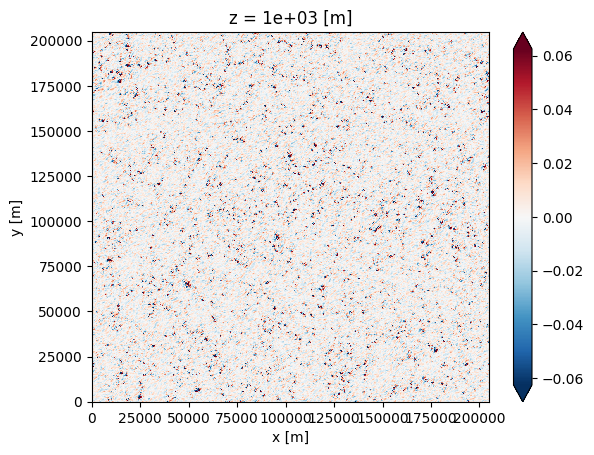

In [25]:
vpg_DL_max = 0.0625
vpg_DL_min = -0.0625
vpg_DL_xr.sel(z=1000, method="nearest").plot(x="x",y="y",vmin=vpg_DL_min,vmax=vpg_DL_max,cmap='RdBu_r')

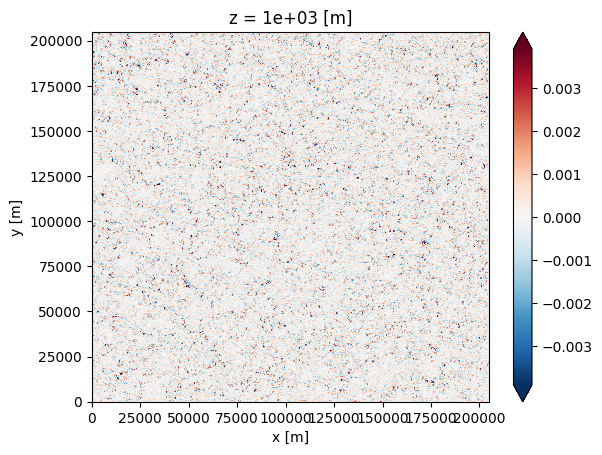

In [31]:
vpg_DN_max = 0.00390625
vpg_DN_min = -0.00390625
vpg_DN_xr.sel(z=1000, method="nearest").plot(x="x",y="y",vmin=vpg_DN_min,vmax=vpg_DN_max,cmap='RdBu_r')

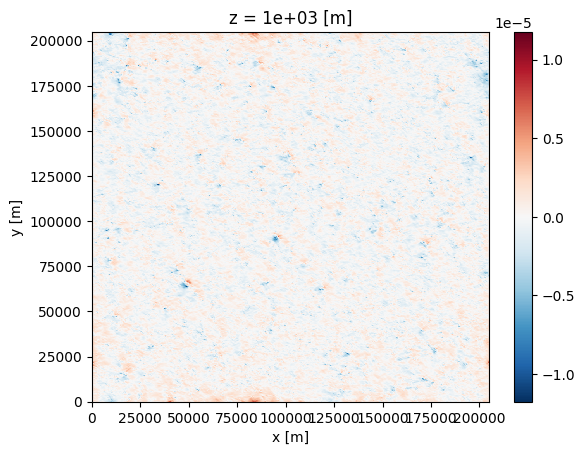

In [33]:
pi_DN_xr.sel(z=1000, method="nearest").plot(x="x",y="y",cmap='RdBu_r')

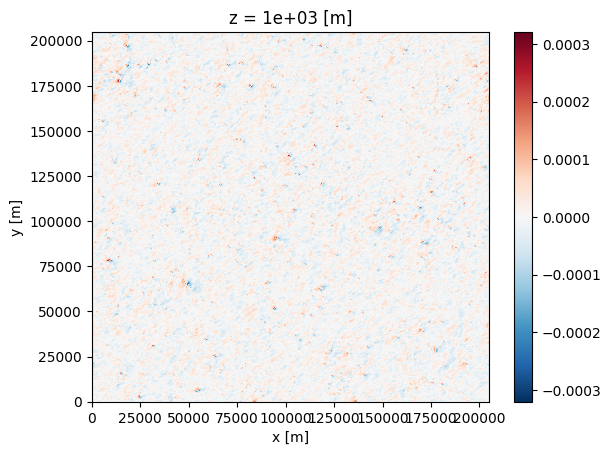

In [34]:
pi_DL_xr.sel(z=1000, method="nearest").plot(x="x",y="y",cmap='RdBu_r')